In [1]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
import xgboost as xgb

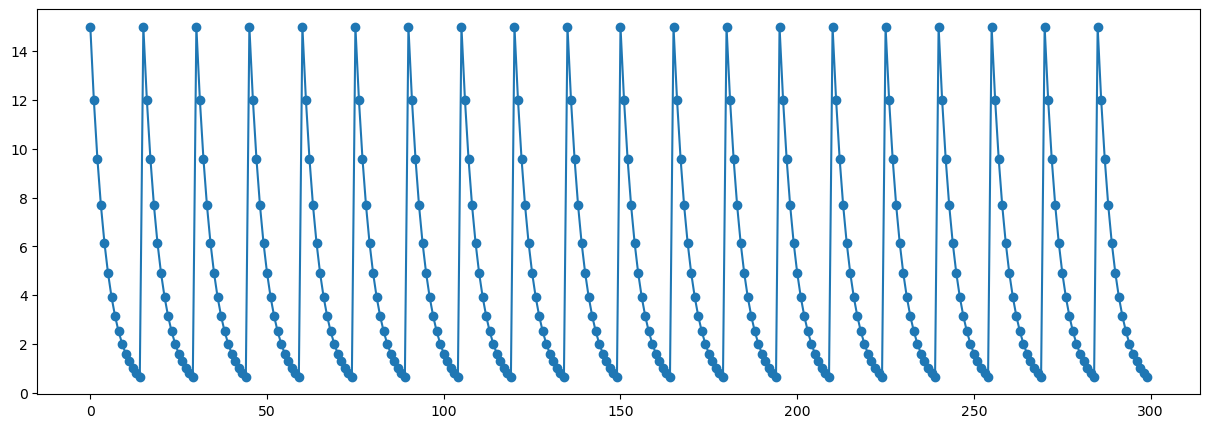

In [2]:
total_steps = 5000000
base_reward = 15.0
decay_rate = 0.8
reward_period = 15 

rewards_in_period = []
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))
plt.figure(figsize=(15, 5))
plt.plot(np.arange(0,300),rewards_in_period[:300],marker = 'o')


def reward_simulate_2d(state, t,rewards_in_period):
    state = np.asarray(state, dtype=int)
    phase = t % 30
    if np.array_equal(state, np.array([1,1])) and phase < 15:
        return float(rewards_in_period[t])
    if np.array_equal(state, np.array([5,5])) and phase >= 15:
        return float(rewards_in_period[t])
    return 0.0

def step_at_bounds(state, action, size=7):
    candidate = state + action
    # If candidate goes out of bounds, stay; else move.
    if (candidate < 0).any() or (candidate >= size).any():
        return state.copy()
    return candidate


def simulate_data_raw(rewards_in_period, session_duration = 10000,tdim=50, n_sessions=10,seed  = 515):
    """
    Simulate training and testing data with rewards from a given environment.


    Returns:
    - actions, state, ireward, times: np.ndarrays
    """

    np.random.seed(seed)
    actions, states, irewards,times = [], [], [], []
    # state_initial = int(np.random.choice(np.arange(7)))
    state_initial = [1,1]
    for episode in range(n_sessions):
        t = 0
        episode_data = []
        state = state_initial
        for _ in range(session_duration):
            ireward = reward_simulate_2d(state, t, rewards_in_period)
            # print(len(state))
            state_vec = np.array([state]).reshape(1,len(state))  # shape (1, state_dim)
            time_emb = time_embedding_np(t+1, tdim=tdim).reshape(1,tdim)
            # print(state_vec.shape,time_emb.shape)
            features = np.hstack([state_vec, time_emb])
            ACTIONS = np.array([[0,1],[0,-1],[-1,0],[1,0],[0,0]], dtype=int)
            idx = np.random.randint(len(ACTIONS))
            action = ACTIONS[idx] # up,down, left right
            next_state = step_at_bounds(state, action, size=7)
            episode_data.append((action,features,ireward))
            state = next_state
            t += 1
        for i, (action, features, ireward) in enumerate(episode_data):
            actions.append(action)
            states.append(features)
            irewards.append(ireward)
            times.append(i)

    return (
        np.array(actions),
        np.array(states),
        np.array(irewards),
        np.array(times),
    )

In [5]:
actions, states, irewards, times = simulate_data_raw(rewards_in_period,session_duration = 1000,tdim = 50,n_sessions = 1)

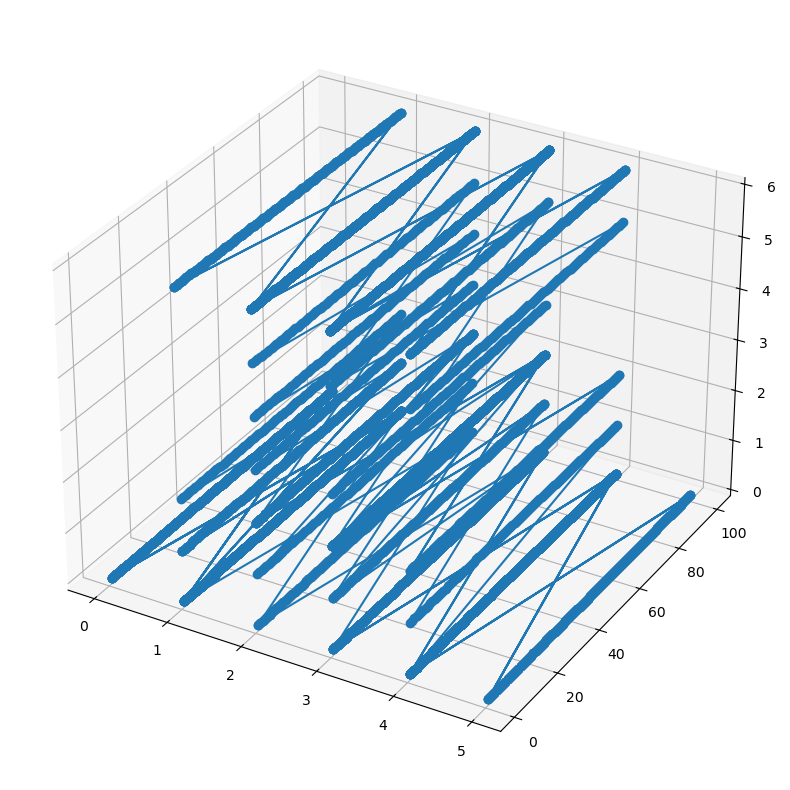

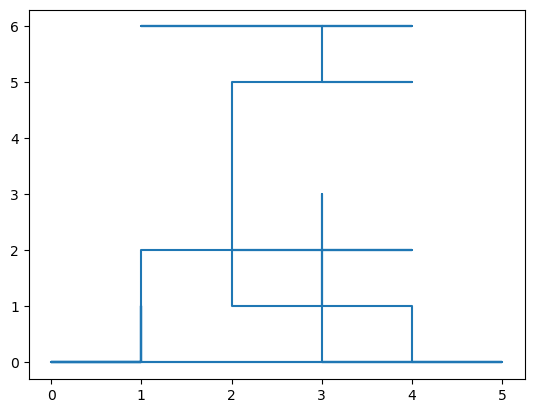

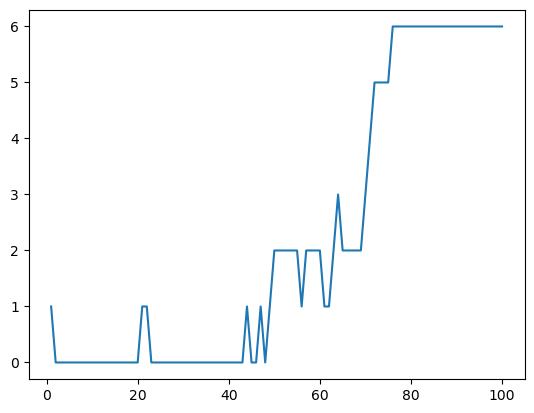

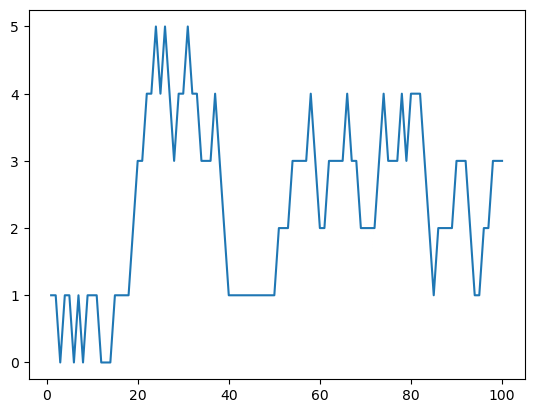

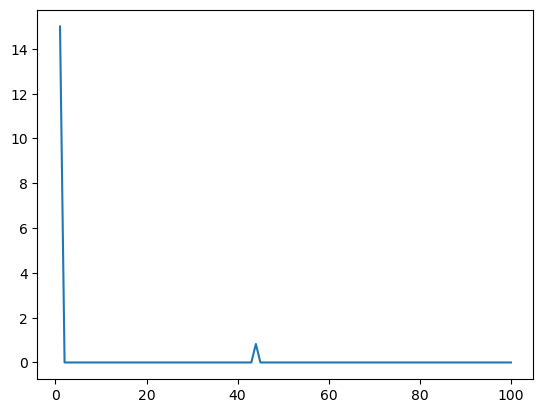

In [6]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot( states[:100,:,0], np.arange(1,101,1),states[:100,:,1], marker='o')
plt.show()
plt.plot(states[:100,:,0],states[:100,:,1])
plt.show()
plt.plot(np.arange(1,101,1),states[:100,:,1])
plt.show()
plt.plot( np.arange(1,101,1),states[:100,:,0])
plt.show()
plt.plot(np.arange(1,101),irewards[:100])

In [7]:
ACTIONS = np.array([[0,1],[0,-1],[-1,0],[1,0],[0,0]], dtype=int)
def _in_bounds(pos, size):
    return 0 <= pos[0] < size and 0 <= pos[1] < size

def get_candidates_2d(state, t, size=7):
    sx, sy = (int(state[0]), int(state[1]))
    curr_state = np.array([sx, sy], dtype=int)
    cands = []
    for d in ACTIONS:
        next_state = curr_state + d
        if _in_bounds(next_state, size):
            cands.append((int(next_state[0]), int(next_state[1])))
        else:
            cands.append((sx, sy))
    seen, uniq = set(), []
    for s in cands:
        if s not in seen:
            seen.add(s)
            uniq.append(s)
    return uniq

def enumerate_paths_2d(x0, t_initial=0, t_prime=20, size=7):
    x0 = (int(x0[0]), int(x0[1]))
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates_2d(curr, t, size=size):
                new_paths.append(path + [nxt])
        paths = new_paths

    cols = [f"t={t_initial+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [8]:
df_paths = enumerate_paths_2d(x0=(0,0), t_initial=0, t_prime=3, size=7)
df_paths

,t=0,t=1,t=2,t=3
0,"(0, 0)","(0, 1)","(0, 2)","(0, 3)"
1,"(0, 0)","(0, 1)","(0, 2)","(0, 1)"
2,"(0, 0)","(0, 1)","(0, 2)","(0, 2)"
3,"(0, 0)","(0, 1)","(0, 2)","(1, 2)"
4,"(0, 0)","(0, 1)","(0, 0)","(0, 1)"
5,"(0, 0)","(0, 1)","(0, 0)","(0, 0)"
6,"(0, 0)","(0, 1)","(0, 0)","(1, 0)"
7,"(0, 0)","(0, 1)","(0, 1)","(0, 2)"
8,"(0, 0)","(0, 1)","(0, 1)","(0, 0)"
9,"(0, 0)","(0, 1)","(0, 1)","(0, 1)"


In [15]:
gamma = 0.9
# Ts = [2**i for i in np.arange(7,8)]+[150,200,225,256,300,400,512]+[750]+[1024,1250,1500,2048]
Ts = [600,1200,3000,6000,12000,24000]
threshold = 1e-4
## Onehot Encoding
for rep in range(2):
    for t_prime in [9]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
        state_posencode_oh_x = position_encoder(states[:,:,0], type="onehot")
        state_posencode_oh_y = position_encoder(states[:,:,1], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh_y,state_posencode_oh_x,states[:,0,2:]])
        # np.random.shuffle(irewards)
        for T in Ts:
            prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)
            X_train_oh = new_state_oh[:T,:]
            Y_train_value = prewards[:T]
            Y_train_action = irewards[:T]
            # is_pos = (Y_train_value > threshold).astype(int)
            # pos = is_pos.sum()
            # neg = len(Y_train_value) - pos
            # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
            rf_value = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            # rf_value.fit(X_train_oh, Y_train_value, sample_weight=w)
            rf_value.fit(X_train_oh, Y_train_value)

            
            rf_action = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            rf_action.fit(X_train_oh, Y_train_action)

            print(T,'train done')
            current_state = states[T,0,:2]
            print(current_state)
            future_states = [current_state]
            for delta_t in range(60):
                df_all_paths = enumerate_paths_2d(x0=current_state,t_initial = T+delta_t,t_prime=t_prime)
                # print(f"Total paths: {len(df_all_paths)}")
                # states_seq = df_all_paths[state_cols].to_numpy() 

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    next_state = df_all_paths.iloc[:,i]
                    next_state_x = np.array([next_state[i][0] for i in range(df_all_paths.shape[0])])
                    next_state_y = np.array([next_state[i][1] for i in range(df_all_paths.shape[0])])
                    cand_pe_x = position_encoder(next_state_x, type="onehot")
                    cand_pe_y = position_encoder(next_state_y, type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe_y.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
                    irewards_pred[:,i] = rf_action.predict(features)
                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)


                next_state = df_all_paths.iloc[:,-1]
                next_state_x = np.array([next_state[i][0] for i in range(df_all_paths.shape[0])])
                next_state_y = np.array([next_state[i][1] for i in range(df_all_paths.shape[0])])
                cand_pe_x = position_encoder(next_state_x, type="onehot")
                cand_pe_y = position_encoder(next_state_y, type="onehot")
                curr_time = T+1+delta_t+t_prime+1
                time_emb = time_embedding_np(np.ones(cand_pe_x.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
                
                prewards_pred = rf_value.predict(features)
                df_ireward[f"preward"] = prewards_pred
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(0, t_prime+1)

                discounted_returns = rewards_matrix * discounts # PVAFM
                # discounted_returns = rewards_matrix[:,:-1] * discounts[:-1] 
                # total_discounted = discounted_returns.sum(axis=1)+ 7*df_ireward.iloc[:,-1].values
                # print(rewards_matrix.shape)
                # Compute discounted total reward per path
                # discounted_returns = rewards_matrix * discounts  
                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = df_all_paths.iloc[bext_idx,1]
                # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
                print(T+delta_t+1,current_state)
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate_2d(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,60,0.5,normalization = True)
            # path, ireward_opt = path_opt(future_states[0], T, 100)
            # preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization = True)
            # pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            # print(pregret)
            # plt.plot(np.arange(T+1,T+101),future_states[1:])
            # plt.plot(np.arange(1,101,1),states[:100,:,1])
            # plt.show()
            # plt.plot( np.arange(1,101,1),states[:100,:,0])
            # plt.show()
            np.savez(
                f"../results/2D/RF_oh_w_time{T}_lookahead{t_prime}_reps{rep}.npz",
                future_states =FUTURE_STATE
                )
        # FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        # np.savez(
        # f"../results/2D/RF_oh_w_time1000_240000_lookahead{t_prime}_reps{rep}.npz",
        # future_states =FUTURE_STATE_arr
        # )

600 train done
[1. 0.]
601 (1, 1)
602 (1, 2)
603 (1, 3)
604 (1, 4)
605 (2, 4)
606 (2, 5)
607 (3, 5)
608 (4, 5)
609 (5, 5)
610 (5, 5)
611 (5, 5)
612 (5, 5)
613 (5, 5)
614 (5, 5)
615 (5, 5)
616 (5, 5)
617 (5, 5)
618 (5, 5)
619 (5, 5)
620 (5, 5)
621 (5, 5)
622 (5, 4)
623 (5, 4)
624 (5, 5)
625 (5, 5)
626 (5, 5)
627 (5, 5)
628 (5, 5)
629 (5, 5)
630 (5, 5)
631 (5, 5)
632 (5, 5)
633 (5, 5)
634 (5, 5)
635 (5, 5)
636 (5, 5)
637 (5, 5)
638 (5, 5)
639 (5, 5)
640 (5, 5)
641 (5, 5)
642 (5, 5)
643 (5, 5)
644 (5, 5)
645 (5, 5)
646 (5, 5)
647 (5, 5)
648 (5, 5)
649 (5, 5)
650 (5, 5)
651 (5, 5)
652 (5, 5)
653 (5, 5)
654 (5, 5)
655 (5, 5)
656 (5, 5)
657 (5, 5)
658 (5, 5)
659 (5, 5)
660 (5, 5)
600 [array([1., 0.]), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (2, 5), (3, 5), (4, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 4), (5, 4), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),

In [16]:
preward

array([ 7.96875693,  6.33751385,  4.9950277 ,  3.8460554 ,  2.77691081,
        1.62166161,  0.09759523,  0.19519046,  0.39038091,  0.78076183,
        1.56152365,  3.12304731,  6.24609462, 12.49218923,  9.98437846,
        7.96875693,  6.33751385,  4.9950277 ,  3.8460554 ,  2.77691081,
        1.62166161,  0.09759523,  0.19519046,  0.39038091,  0.78076183,
        1.56152365,  3.12304731,  6.24609461, 12.49218923,  9.98437846,
        7.96875692,  6.33751384,  4.99502766,  3.84605531,  2.77691059,
        1.62166112,  0.09759405,  0.19518812,  0.39037634,  0.78075305,
        1.56150759,  3.12302113,  6.24606609, 12.4922275 ,  9.98437846,
        7.96863389,  6.33706862,  4.9938093 ,  3.84305671,  2.76986538,
        1.60529622,  0.05882353,  0.11811024,  0.23809524,  0.48387097,
        1.        ,  2.14285714,  5.        , 15.        ,  0.        ])

In [ ]:
np.savez(
                f"../results/2D/RF_oh_w_time{T}_lookahead{t_prime}_reps{rep}.npz",
                future_states =FUTURE_STATE
                )

[0.0,
 9.600000000000001,
 7.6800000000000015,
 6.144000000000001,
 4.915200000000001,
 3.9321600000000014,
 3.145728000000001,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 15.0,
 12.0,
 9.600000000000001,
 7.6800000000000015,
 6.144000000000001,
 4.915200000000001,
 3.9321600000000014,
 3.145728000000001,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 15.0,
 12.0,
 9.600000000000001,
 7.6800000000000015,
 6.144000000000001,
 4.915200000000001,
 3.9321600000000014,
 3.145728000000001,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 15.0,
 12.0,
 9.600000000000001,
 7.6800000000000015,
 6.144000000000001,
 4.915200000000001,
 3.9321600000000014,
 3.145728000000001,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 15.0]

In [40]:
fs1 = [
    (1, 0), (1, 1), (1, 2), (1, 3), (1, 4),
    (2, 4), (2, 5), (3, 5), (4, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 4),
    (5, 4), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),(5, 5), (5, 5)
]

fs2 = [
    (2, 4), (2, 3), (2, 2), (2, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1),
    (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 5),
    (3, 5), (2, 5), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (1, 1), (1, 1), (1, 1),
    (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1),
    (1, 1), (1, 1), (2, 1), (3, 1), (4, 1), (4, 2), (4, 3), (5, 3), (5, 4), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 4), (5, 3), (5, 2), (5, 1), (4, 1), (3, 1), (2, 1),
    (1, 1)
]

fs3 = [
    (2, 3), (2, 2), (2, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1),
    (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (4, 5)
]

fs4 = [
(6, 2), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (1, 1), (1, 1), (1, 2), (1, 3),
    (1, 4), (2, 4), (3, 4), (4, 4), (4, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 4),
    (4, 4), (3, 4), (2, 4), (1, 4), (1, 3), (1, 2), (1, 1), (1, 1), (1, 2), (1, 3),
    (1, 4), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),
    (5, 5), (5, 5), (5, 5), (5, 4), (5, 3), (5, 2), (4, 2), (4, 1), (3, 1), (2, 1),
    (1, 1)
]

fs5 = [(6, 4), (6, 3), (6, 2), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 1), (3, 1),(4, 1), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),(5, 5), (5, 5), (5, 5), (5, 5), (5, 4), (5, 3), (4, 3), (4, 2), (4, 1), (3, 1),(2, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 2), (1, 3),(2, 3), (3, 3), (3, 4), (4, 4), (4, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),(5, 5), (5, 5), (5, 5), (5, 4), (5, 3), (4, 3), (4, 2), (3, 2), (3, 1), (2, 1),(1, 1)]

fs6 = [(5, 4), (4, 4), (3, 4), (2, 4), (1, 4), (1, 3), (1, 2), (1, 1), (1, 2), (1, 3),(1, 4), (2, 4), (2, 5), (3, 5), (4, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),(5, 5), (5, 5), (5, 5), (4, 5), (3, 5), (3, 4), (2, 4), (2, 3), (2, 2), (2, 1),(1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 2), (2, 2),(3, 2), (3, 3), (3, 4), (4, 4), (4, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5),(5, 5), (5, 5), (5, 5), (4, 5), (3, 5), (3, 4), (2, 4), (2, 3), (2, 2), (1, 2),(1, 1)]

paths = [fs1, fs2, fs3, fs4, fs5, fs6]


In [38]:
fs1_1 = [(6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5)] 
fs2_1 =[(2, 3), (2, 2), (2, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5)]
fs3_1 =[(4, 1), (3, 1), (2, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 4), (5, 3), (5, 2), (5, 1), (4, 1), (3, 1), (2, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 4)]
fs4_1 =[(0, 4), (1, 4), (1, 3), (1, 2), (1, 1), (1, 1), (1, 1), (1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (4, 3), (5, 3), (5, 4), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (4, 5), (3, 5), (2, 5), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 4), (4, 4)]
fs5_1 =[(4, 6), (4, 5), (3, 5), (2, 5), (1, 5), (1, 4), (1, 3), (1, 2), (1, 3), (1, 3), (1, 4), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 4), (5, 3), (4, 3), (4, 2), (3, 2), (2, 2), (1, 2), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (3, 4), (4, 4), (5, 4), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 4), (4, 4), (4, 3), (4, 2), (3, 2), (2, 2), (1, 2), (1, 1)] 
fs6_1 =[(3, 1), (2, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (4, 5), (3, 5), (3, 4), (2, 4), (2, 3), (2, 2), (1, 2), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 4), (5, 3), (5, 2), (5, 1), (4, 1), (3, 1), (2, 1), (1, 1)]
paths = [fs1_1, fs2_1, fs3_1, fs4_1, fs5_1, fs6_1]

In [41]:
prewards = []
Ts =  [600,1200,3000,6000,12000,24000]
print(len(FUTURE_STATE))
pregrets = []
for i in np.arange(len(Ts)): 
    T = Ts[i]
    future_states = paths[i]
    np.savez(f"../results/2D/RF_oh_w_time{T}_lookahead{9}_reps{1}.npz",future_states =future_states)
    print(len(future_states))
    irewards_test = [reward_simulate_2d(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    print(irewards_test)
    preward = compute_normalized_future_rewards(irewards_test,60,0.5,normalization = True)
    prewards.append(np.sum(preward))
    pregrets.append((215-(np.sum(preward)))/60)

6
61
[12.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001, 7.6800000000000015, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 0.0, 0.0, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001, 7.6800000000000015, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 3.145728000000001, 2.516582400000001, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0]
61
[0.0, 0.0, 0.0, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 3.145728000000001, 2.516582400000001, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001,

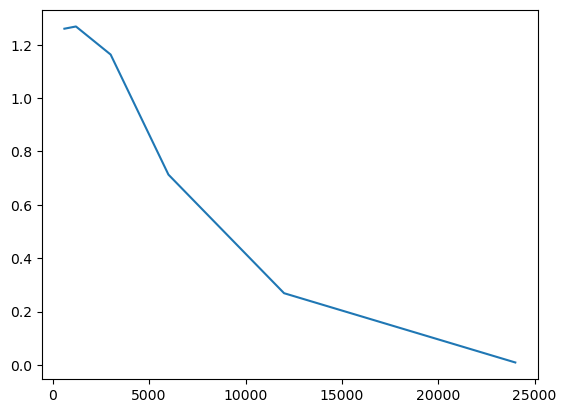

In [25]:
plt.plot(Ts,pregrets)

61
[12.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001, 7.6800000000000015, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 0.0, 0.0, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001, 7.6800000000000015, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 3.145728000000001, 2.516582400000001, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0]
61
[0.0, 0.0, 0.0, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 3.145728000000001, 2.516582400000001, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001, 7

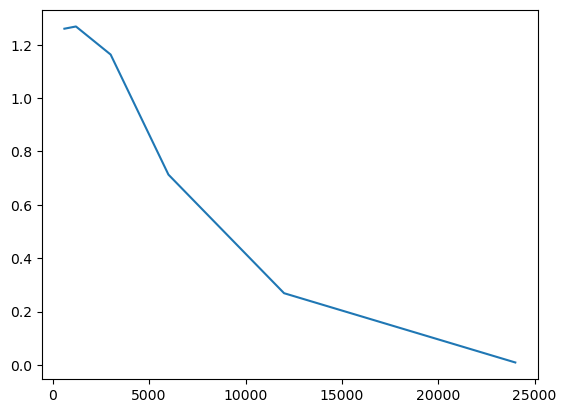

In [53]:
prewards = []
pregrets = []
Ts =  [600,1200,3000,6000,12000,24000]
for T in Ts:
    fn = f"../results/2D/RF_oh_w_time{T}_lookahead9_reps{1}.npz"
    data = np.load(fn)
    future_states = data['future_states']
    print(len(future_states))
    irewards_test = [reward_simulate_2d(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    print(irewards_test)
    preward = compute_normalized_future_rewards(irewards_test,60,0.5,normalization = True)
    prewards.append(np.sum(preward))
    pregrets.append((215-(np.sum(preward)))/60)
plt.plot(Ts,pregrets)